# Collaborative Filtering (协同过滤)
- 协同过滤是一种基于用户行为的推荐算法，它的基本思想是通过分析用户之间的相似度，来推荐用户可能喜欢的物品。
- 协同过滤可以分为基于用户的协同过滤和基于物品的协同过滤两种。
- 基于用户的协同过滤是指根据用户之间的相似度，来推荐用户可能喜欢的物品。
- 基于物品的协同过滤是指根据物品之间的相似度，来推荐用户可能喜欢的物品。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import tensorflow as tf

data = loadmat('data/ex8_movies.mat')
data_params = loadmat('data/ex8_movieParams.mat')
data
# Y 是一个 1682x943 矩阵，它的每一行对应着一个电影，每一列对应着一个用户。
# Y(i,j) 是用户 j 对电影 i 的评分。
# 评分的范围是 1 到 5，其中 1 是最低的评分，5 是最高的评分。
# 如果用户 j 没有对电影 i 进行评分，那么 Y(i,j) 就是 0。

# R 是一个 1682x943 矩阵，它的每一行对应着一个电影，每一列对应着一个用户。
# R(i,j) 是用户 j 是否对电影 i 进行了评分。
# 如果用户 j 对电影 i 进行了评分，那么 R(i,j) 就是 1。
# 如果用户 j 没有对电影 i 进行评分，那么 R(i,j) 就是 0。

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Thu Dec  1 17:19:26 2011',
 '__version__': '1.0',
 '__globals__': [],
 'Y': array([[5, 4, 0, ..., 5, 0, 0],
        [3, 0, 0, ..., 0, 0, 5],
        [4, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'R': array([[1, 1, 0, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 1],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)}

In [2]:
data_params
# X 是一个 1682x10 矩阵，它的每一行对应着一个电影，每一列对应着一个特征。
# X(i,j) 是电影 i 的第 j 个特征。
# 特征的范围是 0 到 1，其中 0 是最低的特征，1 是最高的特征。
# 如果电影 i 没有第 j 个特征，那么 X(i,j) 就是 0。

# Theta 是一个 943x10 矩阵，它的每一行对应着一个用户，每一列对应着一个特征。
# Theta(i,j) 是用户 i 的第 j 个特征。
# 特征的范围是 0 到 1，其中 0 是最低的特征，1 是最高的特征。
# 如果用户 i 没有第 j 个特征，那么 Theta(i,j) 就是 0。

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Thu Dec  1 17:16:53 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[ 1.0486855 , -0.40023196,  1.19411945, ...,  0.861721  ,
         -0.69728994,  0.28874563],
        [ 0.78085123, -0.38562591,  0.52119779, ...,  0.70402073,
         -0.48583521, -0.56462407],
        [ 0.64150886, -0.54785385, -0.08379638, ...,  0.83854643,
         -0.69483208, -1.13479631],
        ...,
        [ 0.21952237, -0.20047886,  0.09257965, ...,  0.14595183,
         -0.0431316 ,  0.17830451],
        [ 0.16044028, -0.16015395,  0.23570946, ...,  0.2073381 ,
         -0.33234766,  0.0428813 ],
        [ 0.07677118, -0.19720738,  0.08186445, ...,  0.40012757,
         -0.28747906, -0.03233498]]),
 'Theta': array([[ 0.28544362, -1.68426509,  0.26293877, ...,  0.76723235,
         -1.10460164, -0.25186708],
        [ 0.50501321, -0.45464846,  0.31746244, ...,  1.09306336,
         -1.20029436, -0.39161676],
        [-0.4319

In [3]:

Actual_rates = data['Y']
Movies_features = data_params['X']
User_features = data_params['Theta']
R = data['R']
print(Actual_rates.shape,Movies_features.shape,User_features.shape,R.shape)

Movies_features = np.hstack((Movies_features,np.ones(Movies_features.shape[0]).reshape(-1,1)))
User_features = np.hstack((User_features,np.ones(User_features.shape[0]).reshape(-1,1)))

mu = np.mean(Actual_rates,axis=1)
print(mu.shape)
Predicted_rates = Movies_features @ User_features.T
accuracy = np.mean((Predicted_rates.astype(int) == Actual_rates.astype(int)))
accuracy


(1682, 943) (1682, 10) (943, 10) (1682, 943)
(1682,)


np.float64(0.029726516052318668)

In [4]:
def predict(User_features:np.ndarray,Movies_features:np.ndarray,mu:np.ndarray) -> np.ndarray:
    # mean normalization
    # print(User_features.shape,Movies_features.shape,mu.shape)
    predicted_rates = Movies_features @ User_features.T + mu.reshape(-1,1)
    return predicted_rates

In [5]:
def cost_func(Predicted_rates:np.ndarray,Actual_rates:np.ndarray,R:np.ndarray,lambda_:float) -> float:
    # mean normalization
    cost = np.sum(np.power((Predicted_rates - Actual_rates)* R,2)) / 2 + \
        lambda_ * np.sum(np.power(User_features[:,:-1],2)) / 2 + \
        lambda_ * np.sum(np.power(Movies_features[:,:-1],2)) / 2
    return cost


In [6]:
predicted_rate = predict(User_features,Movies_features,mu)
cost = cost_func(predicted_rate,Actual_rates,R,0.01)
cost

np.float64(171899.00813410728)

In [7]:
# 修复 predict 函数
def predict(User_features:tf.Variable, Movies_features:tf.Variable, mu:tf.Tensor) -> tf.Tensor:
    # 使用 TensorFlow 的转置操作替代 .T
    predicted_rates = tf.matmul(Movies_features, tf.transpose(User_features)) + tf.reshape(mu, (-1, 1))
    return predicted_rates

# 修复 cost_func 函数
def cost_func(Predicted_rates:tf.Tensor, Actual_rates:tf.Tensor, R:tf.Tensor, 
              User_features:tf.Variable, Movies_features:tf.Variable, lambda_:float) -> tf.Tensor:
    # 使用 TensorFlow 操作替代 NumPy 操作
    cost = tf.reduce_sum(tf.square((Predicted_rates - Actual_rates) * R)) / 2 + \
        lambda_ * tf.reduce_sum(tf.square(User_features[:,:-1])) / 2 + \
        lambda_ * tf.reduce_sum(tf.square(Movies_features[:,:-1])) / 2
    return cost

# 更新 Gradient_descent 函数以适配修复后的 cost_func
def Gradient_descent(
    User_features:tf.Variable, Movies_features:tf.Variable, mu:tf.Tensor, Actual_rates:tf.Tensor, R:tf.Tensor,\
        lambda_:float, init_alpha:float, max_iter:int=1000, tolerance:float=1e-23) -> tf.Tensor:
    history = tf.TensorArray(tf.float32, size=max_iter)
    for i in range(max_iter):
        with tf.GradientTape() as tape:
            predicted_rates = predict(User_features, Movies_features, mu)
            # 传递所有必要的参数给 cost_func
            cost = cost_func(predicted_rates, Actual_rates, R, User_features, Movies_features, lambda_)
        grads = tape.gradient(cost, [User_features, Movies_features])
        User_features.assign_sub(init_alpha * grads[0])
        Movies_features.assign_sub(init_alpha * grads[1])
        history = history.write(i, cost)
        
        if (history.stack()[i-1] > history.stack()[i]):
            init_alpha *= 1.05
        else:
            init_alpha *= 0.5
        # 添加检查以避免在第一次迭代时访问 history.stack()[-2]
        # if abs(history.stack()[i-1] - history.stack()[i]) < tolerance:
        #     break
    # 返回实际迭代次数的历史记录
    return history.stack()[:i+1]

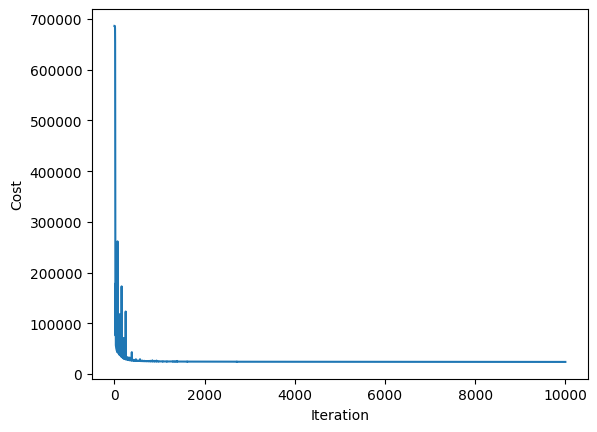

In [8]:
# train the model
num_users = int(data_params['num_users'][0,0])
num_features = int(data_params['num_features'][0,0])
num_movies = int(data_params['num_movies'][0,0])

# Now create the variables with correct scalar dimensions
User_features = tf.Variable(tf.random.normal((num_users, num_features), stddev=0.01))
Movies_features = tf.Variable(tf.random.normal((num_movies, num_features), stddev=0.01))
mu = tf.Variable(tf.zeros(num_movies))

lambda_ = 0.1
init_alpha = 0.001 # 协同过滤对学习率明杆，需要设置很低
max_iter = 10000
tolerance = 1e-6
history = Gradient_descent(User_features,Movies_features,mu,Actual_rates,R,lambda_,init_alpha,max_iter,tolerance)
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.show()


In [9]:
# make a prediction for a user
user_id = 1
predicted_rates = tf.matmul(User_features, Movies_features, transpose_b=True) + mu
predicted_rates = predicted_rates[user_id, :]
# 过滤出用户没有评分过的电影
unrated_movies = tf.where(tf.equal(R[user_id, :], 0))
# 从预测评分中选择未评分电影的评分
predicted_rates_unrated = tf.gather(predicted_rates, unrated_movies)
# 对未评分电影的预测评分进行排序（从高到低）
sorted_indices = tf.argsort(predicted_rates_unrated, direction='DESCENDING')
# 选择 top 10 个电影
top_10_movies = tf.gather(unrated_movies, sorted_indices[:10])
# 打印 top 10 个电影的预测评分
print("Top 10 recommended movies for user", user_id, ":")
for movie_id in top_10_movies.numpy():
    print("Movie ID:", movie_id[0], "Predicted Rating:", predicted_rates_unrated.numpy()[movie_id[0]])




Top 10 recommended movies for user 1 :
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
Movie ID: [1] Predicted Rating: [[2.8813868]]
